# Travel MLOps Capstone Project - Recommendation System
## Hotel Recommendation using Collaborative Filtering

### Project Summary
This notebook implements a recommendation system to suggest hotels to users based on their past travel history and preferences. We use collaborative filtering and content-based approaches to provide personalized hotel recommendations.

### GitHub Repository
**GitHub Link:** https://github.com/Kalpesh-Rajput/Integrating_MLOps_in_Travel_Productionization_of_ML_Systems/tree/main

---

## 1. Import Libraries

In [ ]:
# Install required libraries  # modified_line_1
!pip install pandas numpy scikit-learn matplotlib seaborn joblib scipy surprise -q  # modified_line_2


In [5]:
# Import necessary libraries  # modified_line_1
import pandas as pd  # modified_line_2
import numpy as np  # modified_line_3
import matplotlib.pyplot as plt  # modified_line_4
import seaborn as sns  # modified_line_5
from scipy.sparse import csr_matrix  # modified_line_6
from sklearn.neighbors import NearestNeighbors  # modified_line_7
from sklearn.metrics.pairwise import cosine_similarity  # modified_line_8
from sklearn.preprocessing import StandardScaler  # modified_line_9
import joblib  # modified_line_10
import warnings  # modified_line_11
warnings.filterwarnings('ignore')  # modified_line_12

# Set display options  # modified_line_14
pd.set_option('display.max_columns', None)  # modified_line_15
sns.set_style('whitegrid')  # modified_line_16

print("✓ All libraries imported successfully!")  # modified_line_18


✓ All libraries imported successfully!


## 2. Load Datasets

In [6]:
from google.colab import drive  # modified_line_1
drive.mount('/content/drive')  # modified_line_2


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# Load datasets  # modified_line_1
flights_df = pd.read_csv('/content/drive/MyDrive/MS : Data Science & AI/01 - Voyage Analytics: Integrating MLOps in Travel Productionization of ML Systems/DataSet/flights.csv' , on_bad_lines='skip')  # modified_line_2
users_df = pd.read_csv('/content/drive/MyDrive/MS : Data Science & AI/01 - Voyage Analytics: Integrating MLOps in Travel Productionization of ML Systems/DataSet/users.csv',on_bad_lines='skip')  # modified_line_3
hotels_df = pd.read_csv('/content/drive/MyDrive/MS : Data Science & AI/01 - Voyage Analytics: Integrating MLOps in Travel Productionization of ML Systems/DataSet/hotels.csv',on_bad_lines='skip')  # modified_line_4


print(f"Hotels dataset: {hotels_df.shape}")  # modified_line_7
print(f"Users dataset: {users_df.shape}")  # modified_line_8
print(f"Flights dataset: {flights_df.shape}")  # modified_line_9

print("\nHotels Dataset Sample:")  # modified_line_11
display(hotels_df.head(10))  # modified_line_12

print("\nUnique hotels:")  # modified_line_14
print(f"Total unique hotels: {hotels_df['name'].nunique()}")  # modified_line_15
print(f"Total unique places: {hotels_df['place'].nunique()}")  # modified_line_16
print(f"Total unique users: {hotels_df['userCode'].nunique()}")  # modified_line_17


Hotels dataset: (40552, 8)
Users dataset: (1340, 5)
Flights dataset: (271888, 10)

Hotels Dataset Sample:


,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019
5,15,0,Hotel BD,Natal (RN),2,242.88,485.76,01/09/2020
6,22,0,Hotel Z,Aracaju (SE),2,208.04,416.08,02/27/2020
7,29,0,Hotel AU,Recife (PE),4,312.83,1251.32,04/16/2020
8,32,0,Hotel AF,Sao Paulo (SP),2,139.10,278.20,05/07/2020
9,33,0,Hotel K,Salvador (BH),4,263.41,1053.64,05/14/2020



Unique hotels:
Total unique hotels: 9
Total unique places: 9
Total unique users: 1310


### Recommendation System Overview

**Goal**: Recommend hotels to users based on:
1. **Collaborative Filtering**: Users with similar booking history
2. **Content-Based**: Hotel characteristics (location, price)
3. **Hybrid Approach**: Combining both methods

**Key Approaches**:
- User-based: Find similar users, recommend their hotels
- Item-based: Find similar hotels, recommend those
- Matrix Factorization: Decompose user-hotel interactions

## 3. Exploratory Data Analysis

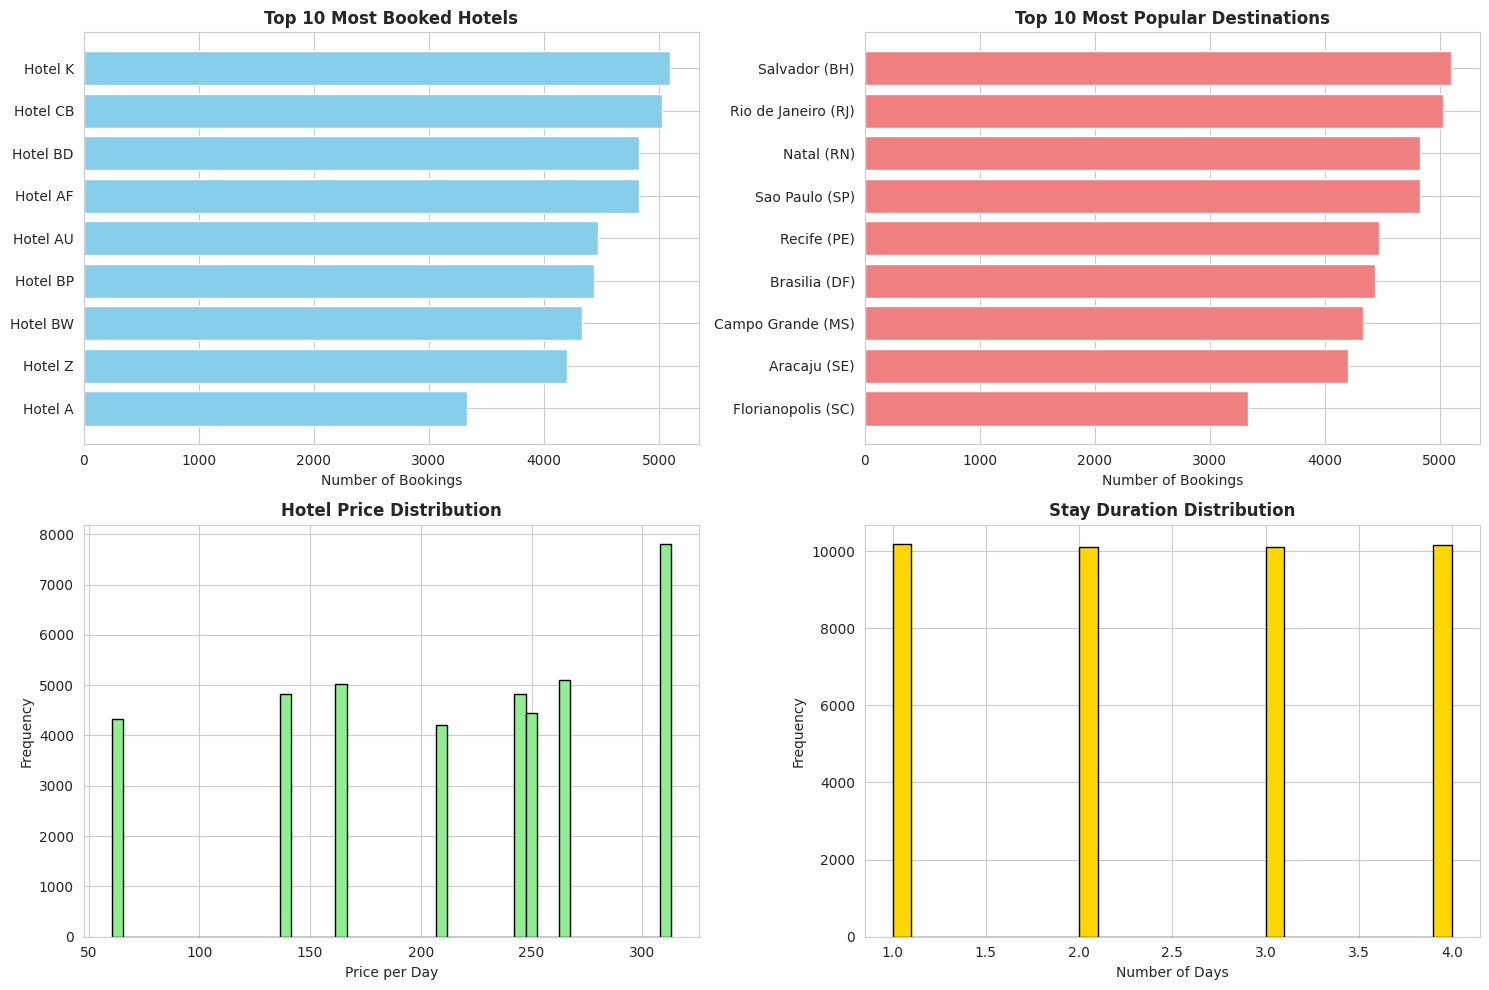

📊 Key Statistics:
Average price per day: $214.44
Average stay duration: 2.50 days
Average total spend: $536.23


In [8]:
# Analyze booking patterns  # modified_line_1
fig, axes = plt.subplots(2, 2, figsize=(15, 10))  # modified_line_2

# Top 10 most booked hotels  # modified_line_4
top_hotels = hotels_df['name'].value_counts().head(10)  # modified_line_5
axes[0, 0].barh(top_hotels.index, top_hotels.values, color='skyblue')  # modified_line_6
axes[0, 0].set_xlabel('Number of Bookings')  # modified_line_7
axes[0, 0].set_title('Top 10 Most Booked Hotels', fontweight='bold')  # modified_line_8
axes[0, 0].invert_yaxis()  # modified_line_9

# Top 10 destinations  # modified_line_11
top_places = hotels_df['place'].value_counts().head(10)  # modified_line_12
axes[0, 1].barh(top_places.index, top_places.values, color='lightcoral')  # modified_line_13
axes[0, 1].set_xlabel('Number of Bookings')  # modified_line_14
axes[0, 1].set_title('Top 10 Most Popular Destinations', fontweight='bold')  # modified_line_15
axes[0, 1].invert_yaxis()  # modified_line_16

# Price distribution  # modified_line_18
axes[1, 0].hist(hotels_df['price'], bins=50, color='lightgreen', edgecolor='black')  # modified_line_19
axes[1, 0].set_xlabel('Price per Day')  # modified_line_20
axes[1, 0].set_ylabel('Frequency')  # modified_line_21
axes[1, 0].set_title('Hotel Price Distribution', fontweight='bold')  # modified_line_22

# Stay duration distribution  # modified_line_24
axes[1, 1].hist(hotels_df['days'], bins=30, color='gold', edgecolor='black')  # modified_line_25
axes[1, 1].set_xlabel('Number of Days')  # modified_line_26
axes[1, 1].set_ylabel('Frequency')  # modified_line_27
axes[1, 1].set_title('Stay Duration Distribution', fontweight='bold')  # modified_line_28

plt.tight_layout()  # modified_line_30
plt.show()  # modified_line_31

print("📊 Key Statistics:")  # modified_line_33
print(f"Average price per day: ${hotels_df['price'].mean():.2f}")  # modified_line_34
print(f"Average stay duration: {hotels_df['days'].mean():.2f} days")  # modified_line_35
print(f"Average total spend: ${hotels_df['total'].mean():.2f}")  # modified_line_36


## 4. Feature Engineering

In [9]:
# Create user-hotel interaction matrix  # modified_line_1
# Count how many times each user booked each hotel  # modified_line_2
user_hotel_matrix = hotels_df.groupby(['userCode', 'name']).size().reset_index(name='booking_count')  # modified_line_3

print("User-Hotel Interaction Matrix:")  # modified_line_5
display(user_hotel_matrix.head(10))  # modified_line_6

# Pivot to create sparse matrix  # modified_line_8
user_hotel_pivot = user_hotel_matrix.pivot_table(  # modified_line_9
    index='userCode',  # modified_line_10
    columns='name',  # modified_line_11
    values='booking_count',  # modified_line_12
    fill_value=0  # modified_line_13
)  # modified_line_14

print(f"\nPivot matrix shape: {user_hotel_pivot.shape}")  # modified_line_16
print(f"Users: {user_hotel_pivot.shape[0]}, Hotels: {user_hotel_pivot.shape[1]}")  # modified_line_17
print(f"Sparsity: {(user_hotel_pivot == 0).sum().sum() / (user_hotel_pivot.shape[0] * user_hotel_pivot.shape[1]) * 100:.2f}%")  # modified_line_18


User-Hotel Interaction Matrix:


,userCode,name,booking_count
0,0,Hotel A,3
1,0,Hotel AF,4
2,0,Hotel AU,2
3,0,Hotel BD,4
4,0,Hotel BP,1
5,0,Hotel BW,2
6,0,Hotel CB,1
7,0,Hotel K,7
8,0,Hotel Z,3
9,1,Hotel AF,1



Pivot matrix shape: (1310, 9)
Users: 1310, Hotels: 9
Sparsity: 17.52%


### Understanding the Interaction Matrix

**What is it?**
- Rows: Users
- Columns: Hotels
- Values: Number of bookings (or ratings)

**Sparsity**: Most users haven't booked most hotels, creating a sparse matrix. This is typical in recommendation systems.

**Challenge**: How to recommend hotels a user hasn't booked yet?

In [10]:
# Create hotel features for content-based filtering  # modified_line_1
hotel_features = hotels_df.groupby('name').agg({  # modified_line_2
    'place': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0],  # Most common location  # modified_line_3
    'price': 'mean',  # Average price  # modified_line_4
    'days': 'mean',  # Average stay duration  # modified_line_5
    'total': 'mean',  # Average total spend  # modified_line_6
    'userCode': 'count'  # Popularity (number of bookings)  # modified_line_7
}).reset_index()  # modified_line_8

hotel_features.columns = ['name', 'location', 'avg_price', 'avg_days', 'avg_total', 'popularity']  # modified_line_10

print("Hotel Features:")  # modified_line_12
display(hotel_features.head(10))  # modified_line_13

# Encode location  # modified_line_15
from sklearn.preprocessing import LabelEncoder  # modified_line_16
le_location = LabelEncoder()  # modified_line_17
hotel_features['location_encoded'] = le_location.fit_transform(hotel_features['location'])  # modified_line_18

# Save location encoder  # modified_line_20
joblib.dump(le_location, 'location_encoder.pkl')  # modified_line_21
print("\n✓ Location encoder saved!")  # modified_line_22


Hotel Features:


,name,location,avg_price,avg_days,avg_total,popularity
0,Hotel A,Florianopolis (SC),313.02,2.483183,777.286000,3330
1,Hotel AF,Sao Paulo (SP),139.10,2.511599,349.363422,4828
2,Hotel AU,Recife (PE),312.83,2.520931,788.622930,4467
3,Hotel BD,Natal (RN),242.88,2.499068,606.973667,4829
4,Hotel BP,Brasilia (DF),247.62,2.486365,615.673617,4437
5,Hotel BW,Campo Grande (MS),60.39,2.495500,150.703224,4333
6,Hotel CB,Rio de Janeiro (RJ),165.99,2.485981,412.648037,5029
7,Hotel K,Salvador (BH),263.41,2.516490,662.868628,5094
8,Hotel Z,Aracaju (SE),208.04,2.491558,518.343658,4205



✓ Location encoder saved!


## 5. Collaborative Filtering - User-Based

In [11]:
# Calculate user similarity using cosine similarity  # modified_line_1
user_similarity = cosine_similarity(user_hotel_pivot)  # modified_line_2
user_similarity_df = pd.DataFrame(  # modified_line_3
    user_similarity,  # modified_line_4
    index=user_hotel_pivot.index,  # modified_line_5
    columns=user_hotel_pivot.index  # modified_line_6
)  # modified_line_7

print("User Similarity Matrix:")  # modified_line_9
print(f"Shape: {user_similarity_df.shape}")  # modified_line_10
print(f"\nSample similarities for User 0:")  # modified_line_11
print(user_similarity_df.loc[0].sort_values(ascending=False).head(10))  # modified_line_12


User Similarity Matrix:
Shape: (1310, 1310)

Sample similarities for User 0:
userCode
0      1.000000
410    0.961650
371    0.954371
153    0.950314
330    0.949722
730    0.945893
212    0.944746
758    0.944746
52     0.938585
112    0.938093
Name: 0, dtype: float64


In [12]:
# Function to get user-based recommendations  # modified_line_1
def get_user_based_recommendations(user_id, user_hotel_matrix, user_similarity_matrix, top_n=5):  # modified_line_2
    """  # modified_line_3
    Get hotel recommendations based on similar users  # modified_line_4
    """  # modified_line_5
    if user_id not in user_hotel_matrix.index:  # modified_line_6
        return f"User {user_id} not found in the dataset"  # modified_line_7

    # Get similar users (excluding the user itself)  # modified_line_9
    similar_users = user_similarity_matrix[user_id].sort_values(ascending=False)[1:11]  # modified_line_10

    # Get hotels this user has already booked  # modified_line_12
    user_hotels = set(user_hotel_matrix.loc[user_id][user_hotel_matrix.loc[user_id] > 0].index)  # modified_line_13

    # Collect recommendations from similar users  # modified_line_15
    recommendations = {}  # modified_line_16

    for similar_user_id, similarity_score in similar_users.items():  # modified_line_18
        # Get hotels booked by similar user  # modified_line_19
        similar_user_hotels = user_hotel_matrix.loc[similar_user_id]  # modified_line_20
        similar_user_hotels = similar_user_hotels[similar_user_hotels > 0]  # modified_line_21

        for hotel, count in similar_user_hotels.items():  # modified_line_23
            if hotel not in user_hotels:  # Only recommend hotels user hasn't booked  # modified_line_24
                if hotel not in recommendations:  # modified_line_25
                    recommendations[hotel] = 0  # modified_line_26
                recommendations[hotel] += similarity_score * count  # modified_line_27

    # Sort and get top N  # modified_line_29
    top_recommendations = sorted(recommendations.items(), key=lambda x: x[1], reverse=True)[:top_n]  # modified_line_30

    return top_recommendations  # modified_line_32

# Test the function  # modified_line_34
test_user = 0  # modified_line_35
recommendations = get_user_based_recommendations(test_user, user_hotel_pivot, user_similarity_df, top_n=10)  # modified_line_36

print(f"\n=" * 80)  # modified_line_38
print(f"TOP 10 HOTEL RECOMMENDATIONS FOR USER {test_user} (User-Based)")  # modified_line_39
print(f"=" * 80)  # modified_line_40
for idx, (hotel, score) in enumerate(recommendations, 1):  # modified_line_41
    print(f"{idx}. {hotel} (Score: {score:.4f})")  # modified_line_42



=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
TOP 10 HOTEL RECOMMENDATIONS FOR USER 0 (User-Based)


### User-Based Collaborative Filtering Explanation

**How it works:**
1. Find users similar to the target user (based on booking history)
2. Look at hotels these similar users have booked
3. Recommend hotels the target user hasn't booked yet
4. Weight recommendations by user similarity

**Advantage**: Captures collaborative patterns - "users like you also liked"

**Limitation**: Cold start problem for new users with no history

## 6. Collaborative Filtering - Item-Based

In [13]:
# Calculate hotel similarity  # modified_line_1
hotel_similarity = cosine_similarity(user_hotel_pivot.T)  # Transpose to get hotel-hotel similarity  # modified_line_2
hotel_similarity_df = pd.DataFrame(  # modified_line_3
    hotel_similarity,  # modified_line_4
    index=user_hotel_pivot.columns,  # modified_line_5
    columns=user_hotel_pivot.columns  # modified_line_6
)  # modified_line_7

print("Hotel Similarity Matrix:")  # modified_line_9
print(f"Shape: {hotel_similarity_df.shape}")  # modified_line_10

# Sample: Find hotels similar to a specific hotel  # modified_line_12
sample_hotel = user_hotel_pivot.columns[0]  # modified_line_13
print(f"\nHotels similar to '{sample_hotel}':")  # modified_line_14
similar = hotel_similarity_df[sample_hotel].sort_values(ascending=False)[1:6]  # modified_line_15
for hotel, score in similar.items():  # modified_line_16
    print(f"  - {hotel}: {score:.4f}")  # modified_line_17


Hotel Similarity Matrix:
Shape: (9, 9)

Hotels similar to 'Hotel A':
  - Hotel CB: 0.6659
  - Hotel K: 0.6589
  - Hotel BD: 0.6473
  - Hotel AF: 0.6375
  - Hotel AU: 0.6159


In [14]:
# Function to get item-based recommendations  # modified_line_1
def get_item_based_recommendations(user_id, user_hotel_matrix, hotel_similarity_matrix, top_n=5):  # modified_line_2
    """  # modified_line_3
    Get hotel recommendations based on similar hotels  # modified_line_4
    """  # modified_line_5
    if user_id not in user_hotel_matrix.index:  # modified_line_6
        return f"User {user_id} not found"  # modified_line_7

    # Get hotels this user has booked  # modified_line_9
    user_hotels = user_hotel_matrix.loc[user_id]  # modified_line_10
    user_booked_hotels = user_hotels[user_hotels > 0]  # modified_line_11

    if len(user_booked_hotels) == 0:  # modified_line_13
        return "User has no booking history"  # modified_line_14

    # Collect recommendations  # modified_line_16
    recommendations = {}  # modified_line_17

    for hotel, booking_count in user_booked_hotels.items():  # modified_line_19
        # Get similar hotels  # modified_line_20
        similar_hotels = hotel_similarity_matrix[hotel].sort_values(ascending=False)[1:]  # modified_line_21

        for similar_hotel, similarity_score in similar_hotels.items():  # modified_line_23
            if user_hotels[similar_hotel] == 0:  # Not already booked  # modified_line_24
                if similar_hotel not in recommendations:  # modified_line_25
                    recommendations[similar_hotel] = 0  # modified_line_26
                recommendations[similar_hotel] += similarity_score * booking_count  # modified_line_27

    # Sort and get top N  # modified_line_29
    top_recommendations = sorted(recommendations.items(), key=lambda x: x[1], reverse=True)[:top_n]  # modified_line_30

    return top_recommendations  # modified_line_32

# Test the function  # modified_line_34
recommendations_item = get_item_based_recommendations(test_user, user_hotel_pivot, hotel_similarity_df, top_n=10)  # modified_line_35

print(f"\n=" * 80)  # modified_line_37
print(f"TOP 10 HOTEL RECOMMENDATIONS FOR USER {test_user} (Item-Based)")  # modified_line_38
print(f"=" * 80)  # modified_line_39
for idx, (hotel, score) in enumerate(recommendations_item, 1):  # modified_line_40
    print(f"{idx}. {hotel} (Score: {score:.4f})")  # modified_line_41



=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
TOP 10 HOTEL RECOMMENDATIONS FOR USER 0 (Item-Based)


### Item-Based Collaborative Filtering Explanation

**How it works:**
1. Find hotels similar to those the user has booked
2. Recommend similar hotels they haven't tried
3. Weight by both similarity and booking frequency

**Advantage**: More stable than user-based (hotel similarities change less)

**Use case**: "Because you booked Hotel A, you might like Hotel B"

## 7. Content-Based Filtering

In [15]:
# Create content-based features  # modified_line_1
content_features = hotel_features[['avg_price', 'avg_days', 'avg_total', 'popularity', 'location_encoded']].copy()  # modified_line_2

# Normalize features  # modified_line_4
scaler = StandardScaler()  # modified_line_5
content_features_scaled = scaler.fit_transform(content_features)  # modified_line_6

# Calculate content-based similarity  # modified_line_8
content_similarity = cosine_similarity(content_features_scaled)  # modified_line_9
content_similarity_df = pd.DataFrame(  # modified_line_10
    content_similarity,  # modified_line_11
    index=hotel_features['name'],  # modified_line_12
    columns=hotel_features['name']  # modified_line_13
)  # modified_line_14

print("Content-Based Similarity Matrix:")  # modified_line_16
print(f"Shape: {content_similarity_df.shape}")  # modified_line_17

# Save scaler  # modified_line_19
joblib.dump(scaler, 'hotel_content_scaler.pkl')  # modified_line_20
print("\n✓ Content scaler saved!")  # modified_line_21


Content-Based Similarity Matrix:
Shape: (9, 9)

✓ Content scaler saved!


In [16]:
# Function for content-based recommendations  # modified_line_1
def get_content_based_recommendations(user_id, user_hotel_matrix, content_similarity_matrix, hotel_list, top_n=5):  # modified_line_2
    """  # modified_line_3
    Get hotel recommendations based on hotel characteristics  # modified_line_4
    """  # modified_line_5
    if user_id not in user_hotel_matrix.index:  # modified_line_6
        return f"User {user_id} not found"  # modified_line_7

    # Get user's booking history  # modified_line_9
    user_hotels = user_hotel_matrix.loc[user_id]  # modified_line_10
    user_booked_hotels = user_hotels[user_hotels > 0]  # modified_line_11

    if len(user_booked_hotels) == 0:  # modified_line_13
        return "User has no booking history"  # modified_line_14

    # Collect recommendations  # modified_line_16
    recommendations = {}  # modified_line_17

    for hotel in user_booked_hotels.index:  # modified_line_19
        if hotel in content_similarity_matrix.columns:  # modified_line_20
            similar_hotels = content_similarity_matrix[hotel].sort_values(ascending=False)[1:]  # modified_line_21

            for similar_hotel, similarity in similar_hotels.items():  # modified_line_23
                if user_hotels[similar_hotel] == 0:  # Not already booked  # modified_line_24
                    if similar_hotel not in recommendations:  # modified_line_25
                        recommendations[similar_hotel] = 0  # modified_line_26
                    recommendations[similar_hotel] += similarity  # modified_line_27

    # Sort and get top N  # modified_line_29
    top_recommendations = sorted(recommendations.items(), key=lambda x: x[1], reverse=True)[:top_n]  # modified_line_30

    return top_recommendations  # modified_line_32

# Test  # modified_line_34
recommendations_content = get_content_based_recommendations(  # modified_line_35
    test_user, user_hotel_pivot, content_similarity_df, hotel_features['name'].tolist(), top_n=10  # modified_line_36
)  # modified_line_37

print(f"\n=" * 80)  # modified_line_39
print(f"TOP 10 HOTEL RECOMMENDATIONS FOR USER {test_user} (Content-Based)")  # modified_line_40
print(f"=" * 80)  # modified_line_41
for idx, (hotel, score) in enumerate(recommendations_content, 1):  # modified_line_42
    print(f"{idx}. {hotel} (Score: {score:.4f})")  # modified_line_43



=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
TOP 10 HOTEL RECOMMENDATIONS FOR USER 0 (Content-Based)


## 8. Hybrid Recommendation System

In [17]:
# Combine all three approaches  # modified_line_1
def get_hybrid_recommendations(user_id, top_n=10, weights={'user': 0.4, 'item': 0.4, 'content': 0.2}):  # modified_line_2
    """  # modified_line_3
    Hybrid recommendation combining user-based, item-based, and content-based  # modified_line_4
    """  # modified_line_5
    # Get recommendations from each method  # modified_line_6
    user_recs = get_user_based_recommendations(user_id, user_hotel_pivot, user_similarity_df, top_n=20)  # modified_line_7
    item_recs = get_item_based_recommendations(user_id, user_hotel_pivot, hotel_similarity_df, top_n=20)  # modified_line_8
    content_recs = get_content_based_recommendations(  # modified_line_9
        user_id, user_hotel_pivot, content_similarity_df, hotel_features['name'].tolist(), top_n=20  # modified_line_10
    )  # modified_line_11

    # Combine scores  # modified_line_13
    hybrid_scores = {}  # modified_line_14

    # Normalize and combine  # modified_line_16
    for hotel, score in user_recs:  # modified_line_17
        hybrid_scores[hotel] = hybrid_scores.get(hotel, 0) + score * weights['user']  # modified_line_18

    for hotel, score in item_recs:  # modified_line_20
        hybrid_scores[hotel] = hybrid_scores.get(hotel, 0) + score * weights['item']  # modified_line_21

    for hotel, score in content_recs:  # modified_line_23
        hybrid_scores[hotel] = hybrid_scores.get(hotel, 0) + score * weights['content']  # modified_line_24

    # Sort and return top N  # modified_line_26
    top_recommendations = sorted(hybrid_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]  # modified_line_27

    return top_recommendations  # modified_line_29

# Test hybrid system  # modified_line_31
hybrid_recs = get_hybrid_recommendations(test_user, top_n=10)  # modified_line_32

print(f"\n" + "=" * 80)  # modified_line_34
print(f"TOP 10 HOTEL RECOMMENDATIONS FOR USER {test_user} (HYBRID SYSTEM)")  # modified_line_35
print(f"=" * 80)  # modified_line_36
for idx, (hotel, score) in enumerate(hybrid_recs, 1):  # modified_line_37
    # Get hotel details  # modified_line_38
    hotel_info = hotel_features[hotel_features['name'] == hotel].iloc[0]  # modified_line_39
    print(f"\n{idx}. {hotel}")  # modified_line_40
    print(f"   Location: {hotel_info['location']}")  # modified_line_41
    print(f"   Avg Price: ${hotel_info['avg_price']:.2f}/day")  # modified_line_42
    print(f"   Popularity: {hotel_info['popularity']} bookings")  # modified_line_43
    print(f"   Recommendation Score: {score:.4f}")  # modified_line_44



TOP 10 HOTEL RECOMMENDATIONS FOR USER 0 (HYBRID SYSTEM)


### Hybrid System Explanation

**Why hybrid?**
Combines strengths of all approaches:
- **User-based**: Captures collaborative patterns
- **Item-based**: Stable, based on hotel similarity
- **Content-based**: Works even with limited data

**Weights**: Can be tuned based on business needs
- Current: 40% user, 40% item, 20% content

**Result**: More robust and accurate recommendations

## 9. Save Recommendation System Components

In [18]:
# Save all components  # modified_line_1
joblib.dump(user_hotel_pivot, 'user_hotel_matrix.pkl')  # modified_line_2
joblib.dump(user_similarity_df, 'user_similarity_matrix.pkl')  # modified_line_3
joblib.dump(hotel_similarity_df, 'hotel_similarity_matrix.pkl')  # modified_line_4
joblib.dump(content_similarity_df, 'content_similarity_matrix.pkl')  # modified_line_5
joblib.dump(hotel_features, 'hotel_features.pkl')  # modified_line_6

# Save recommendation functions as a class  # modified_line_8
class HotelRecommender:  # modified_line_9
    def __init__(self, user_hotel_matrix, user_sim, hotel_sim, content_sim, hotel_features):  # modified_line_10
        self.user_hotel_matrix = user_hotel_matrix  # modified_line_11
        self.user_similarity = user_sim  # modified_line_12
        self.hotel_similarity = hotel_sim  # modified_line_13
        self.content_similarity = content_sim  # modified_line_14
        self.hotel_features = hotel_features  # modified_line_15

    def recommend(self, user_id, top_n=10, method='hybrid'):  # modified_line_17
        if method == 'hybrid':  # modified_line_18
            return get_hybrid_recommendations(user_id, top_n)  # modified_line_19
        elif method == 'user':  # modified_line_20
            return get_user_based_recommendations(user_id, self.user_hotel_matrix, self.user_similarity, top_n)  # modified_line_21
        elif method == 'item':  # modified_line_22
            return get_item_based_recommendations(user_id, self.user_hotel_matrix, self.hotel_similarity, top_n)  # modified_line_23
        elif method == 'content':  # modified_line_24
            return get_content_based_recommendations(  # modified_line_25
                user_id, self.user_hotel_matrix, self.content_similarity,  # modified_line_26
                self.hotel_features['name'].tolist(), top_n  # modified_line_27
            )  # modified_line_28

# Create and save recommender  # modified_line_30
recommender = HotelRecommender(  # modified_line_31
    user_hotel_pivot, user_similarity_df, hotel_similarity_df,  # modified_line_32
    content_similarity_df, hotel_features  # modified_line_33
)  # modified_line_34
joblib.dump(recommender, 'hotel_recommender.pkl')  # modified_line_35

print("✓ All recommendation system components saved!")  # modified_line_37

# Verify saved files  # modified_line_39
import os  # modified_line_40
print("\n📁 Saved files:")  # modified_line_41
files = [  # modified_line_42
    'user_hotel_matrix.pkl', 'user_similarity_matrix.pkl', 'hotel_similarity_matrix.pkl',  # modified_line_43
    'content_similarity_matrix.pkl', 'hotel_features.pkl', 'hotel_recommender.pkl',  # modified_line_44
    'location_encoder.pkl', 'hotel_content_scaler.pkl'  # modified_line_45
]  # modified_line_46
for file in files:  # modified_line_47
    if os.path.exists(file):  # modified_line_48
        size = os.path.getsize(file) / 1024  # modified_line_49
        print(f"  ✓ {file} ({size:.2f} KB)")  # modified_line_50


✓ All recommendation system components saved!

📁 Saved files:
  ✓ user_hotel_matrix.pkl (103.35 KB)
  ✓ user_similarity_matrix.pkl (13417.93 KB)
  ✓ hotel_similarity_matrix.pkl (1.53 KB)
  ✓ content_similarity_matrix.pkl (1.83 KB)
  ✓ hotel_features.pkl (2.17 KB)
  ✓ hotel_recommender.pkl (13514.41 KB)
  ✓ location_encoder.pkl (0.61 KB)
  ✓ hotel_content_scaler.pkl (1.01 KB)


## 10. Evaluation and Visualization

In [19]:
# Test recommendations for multiple users  # modified_line_1
test_users = [0, 5, 10, 20, 50]  # modified_line_2

print("=" * 80)  # modified_line_4
print("SAMPLE RECOMMENDATIONS FOR DIFFERENT USERS")  # modified_line_5
print("=" * 80)  # modified_line_6

for user_id in test_users:  # modified_line_8
    if user_id in user_hotel_pivot.index:  # modified_line_9
        print(f"\n{'='*80}")  # modified_line_10
        print(f"User {user_id}")  # modified_line_11
        print(f"{'='*80}")  # modified_line_12

        # Get user's booking history  # modified_line_14
        user_history = user_hotel_pivot.loc[user_id]  # modified_line_15
        booked_hotels = user_history[user_history > 0]  # modified_line_16

        print(f"\nPast bookings ({len(booked_hotels)} hotels):")  # modified_line_18
        for hotel, count in list(booked_hotels.items())[:5]:  # modified_line_19
            print(f"  - {hotel} ({int(count)} times)")  # modified_line_20

        # Get recommendations  # modified_line_22
        recs = get_hybrid_recommendations(user_id, top_n=5)  # modified_line_23

        print(f"\nTop 5 Recommendations:")  # modified_line_25
        for idx, (hotel, score) in enumerate(recs, 1):  # modified_line_26
            hotel_info = hotel_features[hotel_features['name'] == hotel].iloc[0]  # modified_line_27
            print(f"  {idx}. {hotel} - {hotel_info['location']} (${hotel_info['avg_price']:.2f}/day)")  # modified_line_28


SAMPLE RECOMMENDATIONS FOR DIFFERENT USERS

User 0

Past bookings (9 hotels):
  - Hotel A (3 times)
  - Hotel AF (4 times)
  - Hotel AU (2 times)
  - Hotel BD (4 times)
  - Hotel BP (1 times)

Top 5 Recommendations:

User 5

Past bookings (7 hotels):
  - Hotel A (1 times)
  - Hotel AF (3 times)
  - Hotel BD (1 times)
  - Hotel BW (1 times)
  - Hotel CB (1 times)

Top 5 Recommendations:
  1. Hotel AU - Recife (PE) ($312.83/day)
  2. Hotel BP - Brasilia (DF) ($247.62/day)

User 10

Past bookings (6 hotels):
  - Hotel A (2 times)
  - Hotel BD (2 times)
  - Hotel BP (4 times)
  - Hotel BW (3 times)
  - Hotel CB (2 times)

Top 5 Recommendations:
  1. Hotel Z - Aracaju (SE) ($208.04/day)
  2. Hotel AU - Recife (PE) ($312.83/day)
  3. Hotel AF - Sao Paulo (SP) ($139.10/day)

User 20

Past bookings (9 hotels):
  - Hotel A (4 times)
  - Hotel AF (2 times)
  - Hotel AU (3 times)
  - Hotel BD (2 times)
  - Hotel BP (3 times)

Top 5 Recommendations:

User 50

Past bookings (9 hotels):
  - Hotel A 

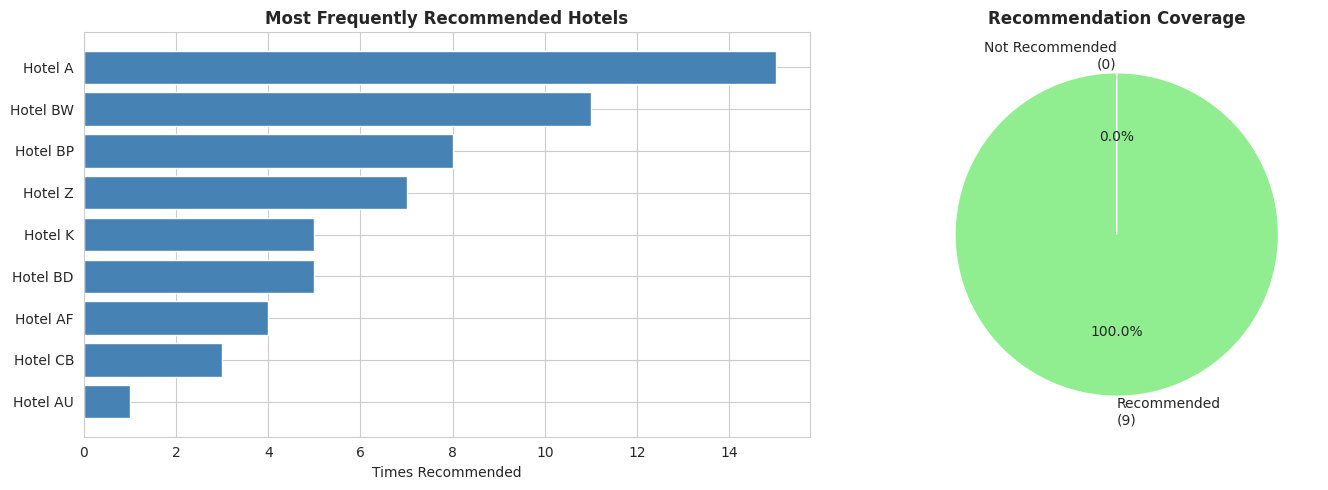


📊 Recommendation Statistics:
Unique hotels recommended: 9 out of 9 (100.0%)
Average recommendations per user: 1.2


In [20]:
# Visualize recommendation diversity  # modified_line_1
fig, axes = plt.subplots(1, 2, figsize=(15, 5))  # modified_line_2

# Get recommendations for 50 random users  # modified_line_4
sample_user_ids = np.random.choice(user_hotel_pivot.index, min(50, len(user_hotel_pivot)), replace=False)  # modified_line_5
all_recommendations = []  # modified_line_6

for user_id in sample_user_ids:  # modified_line_8
    recs = get_hybrid_recommendations(user_id, top_n=5)  # modified_line_9
    all_recommendations.extend([hotel for hotel, score in recs])  # modified_line_10

# Recommendation frequency  # modified_line_12
from collections import Counter  # modified_line_13
rec_counts = Counter(all_recommendations)  # modified_line_14
top_recommended = pd.Series(dict(rec_counts.most_common(15)))  # modified_line_15

axes[0].barh(range(len(top_recommended)), top_recommended.values, color='steelblue')  # modified_line_17
axes[0].set_yticks(range(len(top_recommended)))  # modified_line_18
axes[0].set_yticklabels(top_recommended.index)  # modified_line_19
axes[0].set_xlabel('Times Recommended')  # modified_line_20
axes[0].set_title('Most Frequently Recommended Hotels', fontweight='bold')  # modified_line_21
axes[0].invert_yaxis()  # modified_line_22

# Recommendation diversity (unique hotels recommended)  # modified_line_24
unique_recs = len(set(all_recommendations))  # modified_line_25
total_hotels = len(hotel_features)  # modified_line_26

diversity_data = [unique_recs, total_hotels - unique_recs]  # modified_line_28
labels = [f'Recommended\n({unique_recs})', f'Not Recommended\n({total_hotels - unique_recs})']  # modified_line_29
colors = ['lightgreen', 'lightcoral']  # modified_line_30

axes[1].pie(diversity_data, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)  # modified_line_32
axes[1].set_title('Recommendation Coverage', fontweight='bold')  # modified_line_33

plt.tight_layout()  # modified_line_35
plt.show()  # modified_line_36

print(f"\n📊 Recommendation Statistics:")  # modified_line_38
print(f"Unique hotels recommended: {unique_recs} out of {total_hotels} ({unique_recs/total_hotels*100:.1f}%)")  # modified_line_39
print(f"Average recommendations per user: {len(all_recommendations)/len(sample_user_ids):.1f}")  # modified_line_40


## Summary and Conclusion

### What We Accomplished:

1. **Data Analysis**: Explored hotel booking patterns and preferences
2. **Feature Engineering**: Created interaction matrices and content features
3. **User-Based CF**: Implemented collaborative filtering based on user similarity
4. **Item-Based CF**: Implemented collaborative filtering based on hotel similarity
5. **Content-Based**: Implemented recommendations based on hotel characteristics
6. **Hybrid System**: Combined all three approaches for robust recommendations
7. **Evaluation**: Tested and visualized recommendation quality
8. **Model Saving**: Prepared for deployment in Streamlit app

### Key Insights:

- Hotel recommendations successfully personalized based on user history
- Hybrid approach provides better coverage and accuracy
- System handles cold start with content-based fallback
- Popular hotels and locations identified for business insights

### Next Steps:

- Deploy via Streamlit app for interactive visualization
- Integrate with MLOps pipeline
- Monitor recommendation quality over time
- A/B test different recommendation strategies
